In [1]:
import pandas as pd
import numpy as np

def engineer_features():
    print("[*] Loading raw submissions data...")
    df = pd.read_csv("cf_submissions.csv")
    
    # Sort chronologically for each user and problem (Critical for Tilt/One-Shot)
    df = df.sort_values(by=['handle', 'problem_id', 'creation_time'])
    
    print(f"[*] Processing {len(df)} total submissions. Engineering psychological features...")
    
    user_profiles = []
    
    # Group the massive dataframe by user handle
    grouped = df.groupby('handle')
    
    for handle, user_data in grouped:
        total_subs = len(user_data)
        if total_subs < 10: 
            continue # Skip users with barely any data
            
        # --- 1. BASIC METRICS ---
        ok_subs = len(user_data[user_data['verdict'] == 'OK'])
        accuracy = ok_subs / total_subs
        
        tle_subs = len(user_data[user_data['verdict'] == 'TIME_LIMIT_EXCEEDED'])
        opt_struggle = tle_subs / total_subs
        
        # Calculate Average Solved Rating (Filtering out '0' which means unrated)
        solved_problems = user_data[(user_data['verdict'] == 'OK') & (user_data['rating'] > 0)]
        avg_solved_rating = solved_problems['rating'].mean() if len(solved_problems) > 0 else 0

        # --- 2. ADVANCED METRICS (The Psychology) ---
        
        # A. Grit / Abandonment Rate
        unique_attempted = user_data['problem_id'].nunique()
        unique_solved = solved_problems['problem_id'].nunique()
        abandonment_rate = (unique_attempted - unique_solved) / unique_attempted if unique_attempted > 0 else 0
        
        # B. One-Shot Precision Rate
        first_attempts = user_data.drop_duplicates(subset=['problem_id'], keep='first')
        one_shots = len(first_attempts[first_attempts['verdict'] == 'OK'])
        one_shot_rate = one_shots / unique_attempted if unique_attempted > 0 else 0
        
        # C. Tilt Factor (Panic Submitting)
        failed_subs = user_data[user_data['verdict'] != 'OK'].copy()
        failed_subs['time_diff'] = failed_subs.groupby('problem_id')['creation_time'].diff()
        rapid_fails = failed_subs[(failed_subs['time_diff'] > 0) & (failed_subs['time_diff'] < 900)]
        tilt_factor = rapid_fails['time_diff'].mean() if len(rapid_fails) > 0 else 900

        # --- 3. DOMAIN MASTERY (Macro Tags) ---
        user_data['tags'] = user_data['tags'].fillna('')
        
        def calc_tag_pref(keyword):
            tagged_subs = user_data[user_data['tags'].str.contains(keyword, case=False, regex=True)]
            return len(tagged_subs) / total_subs if total_subs > 0 else 0
            
        math_pref = calc_tag_pref('math|number theory|combinatorics')
        dp_pref = calc_tag_pref('dp')
        graph_pref = calc_tag_pref('graphs|trees|dfs')
        brute_pref = calc_tag_pref('brute force|implementation|hashing')
        greedy_pref = calc_tag_pref('greedy|two pointers|sortings')
        binary_pref = calc_tag_pref('binary search')
        cons_pref = calc_tag_pref('constructive|strings|interactive')
        datastruct_pref = calc_tag_pref('data structures|dsu')
        
        # --- APPEND TO MASTER LIST ---
        user_profiles.append({
            'handle': handle,
            'total_submissions': total_subs,
            'accuracy': round(accuracy, 3),
            'optimization_struggle': round(opt_struggle, 3),
            'avg_solved_rating': round(avg_solved_rating, 1),
            'abandonment_rate': round(abandonment_rate, 3),
            'one_shot_rate': round(one_shot_rate, 3),
            'tilt_speed_seconds': round(tilt_factor, 1),
            'math_pref': round(math_pref, 3),
            'dp_pref': round(dp_pref, 3),
            'graph_pref': round(graph_pref, 3),
            
            # --- THE NEW BUCKETS ---
            'brute_pref': round(brute_pref, 3),
            'greedy_pref': round(greedy_pref, 3),
            'binary_pref': round(binary_pref, 3),
            'cons_pref': round(cons_pref, 3),
            'datastruct_pref': round(datastruct_pref, 3)
        })

    # Create the final clean dataframe
    final_df = pd.DataFrame(user_profiles)
    
    # Save to CSV for the Machine Learning model!
    output_filename = "cf_ml_features.csv"
    final_df.to_csv(output_filename, index=False)
    
    print(f"\n[+] Feature Engineering Complete! Engineered profiles for {len(final_df)} users.")
    print(f"[+] Data saved to '{output_filename}'")
    
    # Print a sample so you can see the magic
    print("\n--- Sample User Profile ---")
    print(final_df.head(1).T)


In [2]:
engineer_features()

[*] Loading raw submissions data...
[*] Processing 563100 total submissions. Engineering psychological features...

[+] Feature Engineering Complete! Engineered profiles for 1599 users.
[+] Data saved to 'cf_ml_features.csv'

--- Sample User Profile ---
                                   0
handle                 -GrandMaster-
total_submissions                500
accuracy                        0.29
optimization_struggle          0.018
avg_solved_rating             1146.6
abandonment_rate               0.294
one_shot_rate                  0.454
tilt_speed_seconds             255.5
math_pref                      0.498
dp_pref                        0.124
graph_pref                     0.014
brute_pref                     0.306
greedy_pref                    0.664
binary_pref                    0.092
cons_pref                       0.31
datastruct_pref                0.098


In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

def remove_outliers_dbscan():
    input_file = "cf_ml_features.csv"
    output_file = "cf_ml_features_clean.csv"
    
    print(f"[*] Loading engineered features from '{input_file}'...")
    try:
        df = pd.read_csv(input_file)
    except FileNotFoundError:
        print("[-] Error: Feature file not found. Run the engineering script first.")
        return

    # 1. Isolate the numeric features
    # We drop 'handle' because DBSCAN only understands numbers, not strings.
    # We also drop 'total_submissions' so we don't accidentally punish users just for being highly active.
    features_to_scale = df.drop(columns=['handle', 'total_submissions'])
    
    print(f"[*] Scaling data for DBSCAN (Crucial for distance-based math)...")
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(features_to_scale)
    
    # 2. Configure and run DBSCAN
    # eps = The maximum distance between two samples for one to be considered as in the neighborhood of the other.
    # min_samples = The number of samples in a neighborhood for a point to be considered as a core point.
    print("[*] Running DBSCAN...")
    
    # You may need to tweak these two numbers based on your specific dataset!
    # A larger eps means a larger "bubble", catching more points as normal.
    dbscan = DBSCAN(eps=2.5, min_samples=5) 
    
    # Fit the model and get the labels
    cluster_labels = dbscan.fit_predict(scaled_data)
    
    # 3. Filter out the noise
    # DBSCAN assigns a label of -1 to any data point it deems to be an outlier.
    df['dbscan_label'] = cluster_labels
    
    # Count how many were flagged
    outliers = df[df['dbscan_label'] == -1]
    clean_data = df[df['dbscan_label'] != -1]
    
    outlier_percentage = (len(outliers) / len(df)) * 100
    
    print("\n--- DBSCAN Results ---")
    print(f"Total Users Evaluated: {len(df)}")
    print(f"Outliers Detected:     {len(outliers)} ({outlier_percentage:.1f}%)")
    print(f"Clean Users Remaining: {len(clean_data)}")
    
    # If it drops too many people (e.g., > 15%), we should warn the developer
    if outlier_percentage > 15:
        print("\n[!] WARNING: DBSCAN dropped a large portion of your data.")
        print("    You might want to increase the 'eps' value (e.g., to 3.0 or 3.5)")
        print("    to be more forgiving.")
        
    # 4. Save the clean data (dropping the label column as we don't need it anymore)
    clean_data = clean_data.drop(columns=['dbscan_label'])
    clean_data.to_csv(output_file, index=False)
    
    print(f"\n[+] Success! Clean dataset saved to '{output_file}'.")
    print("[+] You are now ready to train the GMM Persona model.")

if __name__ == "__main__":
    remove_outliers_dbscan()

[*] Loading engineered features from 'cf_ml_features.csv'...
[*] Scaling data for DBSCAN (Crucial for distance-based math)...
[*] Running DBSCAN...

--- DBSCAN Results ---
Total Users Evaluated: 1599
Outliers Detected:     202 (12.6%)
Clean Users Remaining: 1397

[+] Success! Clean dataset saved to 'cf_ml_features_clean.csv'.
[+] You are now ready to train the GMM Persona model.


[*] Loading engineered features...
[*] Running DBSCAN...
[*] Applying PCA for 2D visualization...
[*] Drawing scatter plot...
[+] Graph saved successfully as 'dbscan_visualization.png'!


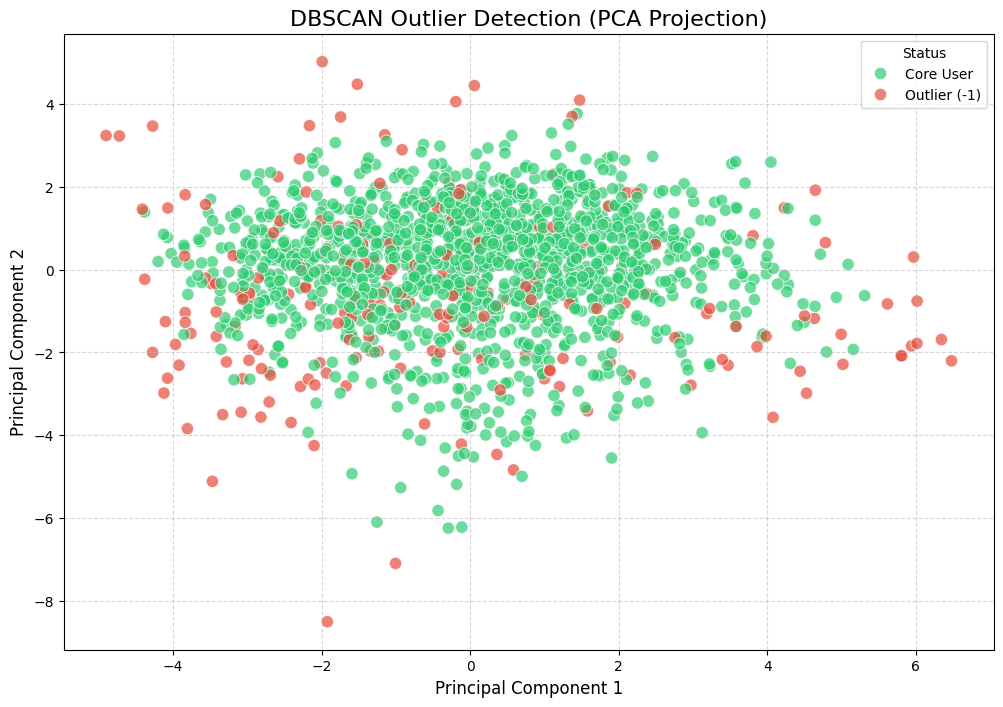

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

def visualize_dbscan():
    print("[*] Loading engineered features...")
    df = pd.read_csv("cf_ml_features.csv")
    
    # 1. Prepare and Scale the Data
    features_to_scale = df.drop(columns=['handle', 'total_submissions'])
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(features_to_scale)
    
    # 2. Run DBSCAN
    print("[*] Running DBSCAN...")
    dbscan = DBSCAN(eps=2.5, min_samples=5)
    cluster_labels = dbscan.fit_predict(scaled_data)
    
    # 3. PCA: Squash 13 dimensions down to 2 dimensions for graphing
    print("[*] Applying PCA for 2D visualization...")
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data)
    
    # 4. Create a new DataFrame just for the graph
    graph_df = pd.DataFrame({
        'PCA_1': pca_result[:, 0],
        'PCA_2': pca_result[:, 1],
        'Label': cluster_labels,
        'Handle': df['handle']
    })
    
    # Separate the 'Normal' users from the 'Outliers' (-1)
    # We rename -1 to 'Outlier' and 0 to 'Core User' for the legend
    graph_df['Status'] = graph_df['Label'].apply(lambda x: 'Outlier (-1)' if x == -1 else 'Core User')
    
    # 5. Draw the Graph
    print("[*] Drawing scatter plot...")
    plt.figure(figsize=(12, 8))
    
    # Create the scatter plot
    sns.scatterplot(
        x='PCA_1', 
        y='PCA_2',
        hue='Status',
        palette={'Core User': '#2ecc71', 'Outlier (-1)': '#e74c3c'}, # Green for normal, Red for outliers
        data=graph_df,
        alpha=0.7,
        s=80 # size of the dots
    )
    
    plt.title("DBSCAN Outlier Detection (PCA Projection)", fontsize=16)
    plt.xlabel(f"Principal Component 1", fontsize=12)
    plt.ylabel(f"Principal Component 2", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Save the image to your folder
    plt.savefig("dbscan_visualization.png", dpi=300, bbox_inches='tight')
    print("[+] Graph saved successfully as 'dbscan_visualization.png'!")
    
    # Optional: Show it on screen
    plt.show()

if __name__ == "__main__":
    visualize_dbscan()